# Modeling News Spread

## Import packages and data

In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
from skimage.graph import MCP_Geometric
from shapely.geometry import Point
from pathlib import Path
import matplotlib.pyplot as plt

# Define Paths relative to project root
PROJECT_ROOT = Path.cwd().parent
RAW = PROJECT_ROOT / 'Data' / 'Raw'
PROCESSED = PROJECT_ROOT / 'Data' / 'Processed'
BNG = RAW / 'GIS/BNG Projections'

# Load Data
print("Loading Data...")
north_parish_flows = gpd.read_file(PROCESSED / 'northParishFlows.shp')
counties_base = gpd.read_file(BNG / 'countiesBNG.shp')
louth_park = gpd.read_file(BNG / 'LouthParkAbbey.shp')
direct_evidence = gpd.read_file(BNG / 'direct_evidence.shp')
indirect_evidence = gpd.read_file(BNG / 'indirect_evidence.shp')
gough_routes = gpd.read_file(BNG / 'gough_routes.shp')
shipping = gpd.read_file(BNG / 'shippingDissolved.shp')
ancient_parishes = gpd.read_file(BNG / 'AncientParishesBNG.shp')

# Define northern counties
north_list = ['NORTHUMBERLAND', 'CUMBERLAND', 'DURHAM', 'WESTMORLAND',
              'YORKSHIRE, NORTH RIDING', 'LANCASHIRE', 'YORKSHIRE, WEST RIDING',
              'YORKSHIRE, EAST RIDING', 'LINCOLNSHIRE']

# Ensure all are in the same CRS (British National Grid)
target_crs = north_parish_flows.crs
print(f"Target CRS: {target_crs}")

for gdf in [louth_park, direct_evidence, indirect_evidence, gough_routes, shipping, ancient_parishes]:
    if gdf.crs != target_crs:
        print(f"Reprojecting {gdf}...")
        gdf.to_crs(target_crs, inplace=True)

Loading Data...
Target CRS: EPSG:27700


## Define Grid

In [10]:
print("Defining Grid...")
# Define bounds with 20km buffer
minx, miny, maxx, maxy = north_parish_flows.total_bounds
buffer_dist = 20000
minx -= buffer_dist
miny -= buffer_dist
maxx += buffer_dist
maxy += buffer_dist

# Grid resolution (1km)
res = 1000
width = int((maxx - minx) / res)
height = int((maxy - miny) / res)

transform = from_origin(minx, maxy, res, res)
print(f"Grid Size: {width} x {height}")
print(f"Bounds: {minx}, {miny}, {maxx}, {maxy}")

Defining Grid...
Grid Size: 303 x 392
Bounds: 273790.625, 285512.6875, 577604.9375, 677600.1875


## Create Cost Surface

In [11]:
print("Creating Cost Surface...")
# Initialize with high cost (background)
cost_grid = np.full((height, width), 0.2, dtype=np.float32)

# Function to rasterize and update minimum cost
def rasterize_and_update(gdf, cost_value, existing_grid, transform, shape):
    shapes = ((geom, cost_value) for geom in gdf.geometry)
    feature_grid = rasterize(
        shapes,
        out_shape=shape,
        transform=transform,
        fill=np.inf, # Use infinity for background to facilitate minimization
        dtype=np.float32,
        all_touched=True
    )
    return np.minimum(existing_grid, feature_grid)

# Rasterize layers
# 1. Land (General movement) - Cost 0.05
print("Rasterizing Land (0.05)...")
cost_grid = rasterize_and_update(counties_base, 0.05, cost_grid, transform, (height, width))

# 2. Roads and Evidence - Cost 0.02
print("Rasterizing Roads/Evidence (0.02)...")
for gdf in [direct_evidence, indirect_evidence, gough_routes]:
    cost_grid = rasterize_and_update(gdf, 0.02, cost_grid, transform, (height, width))

# 3. Shipping - Cost 0.01
print("Rasterizing Shipping (0.01)...")
cost_grid = rasterize_and_update(shipping, 0.01, cost_grid, transform, (height, width))

Creating Cost Surface...
Rasterizing Land (0.05)...
Rasterizing Roads/Evidence (0.02)...
Rasterizing Shipping (0.01)...


## Calculate Least Cost Path

In [12]:
print("Calculating Least Cost Paths...")
# Get Source Node (Louth Park Abbey)
source_geom = louth_park.geometry.iloc[0]
if isinstance(source_geom, Point):
    src_x, src_y = source_geom.x, source_geom.y
else:
    src_x, src_y = source_geom.centroid.x, source_geom.centroid.y

# Convert to matrix coordinates
# ~transform gives the inverse transform
inv_transform = ~transform
col, row = inv_transform * (src_x, src_y)
src_r, src_c = int(row), int(col)

# Initialize MCP with fully_connected=False for 4-connectivity (no diagonals)
mcp = MCP_Geometric(cost_grid, fully_connected=False)

# Calculate cumulative costs from source to all other points
cumulative_costs, traceback = mcp.find_costs([(src_r, src_c)])

Calculating Least Cost Paths...


## Extract Costs for Parishes

In [13]:
print("Extracting costs for parishes...")
# Function to get cost at centroid
def get_cost_at_centroid(geom):
    cx, cy = geom.centroid.x, geom.centroid.y
    c, r = inv_transform * (cx, cy)
    r, c = int(r), int(c)
    
    # Check bounds
    if 0 <= r < height and 0 <= c < width:
        return cumulative_costs[r, c]
    else:
        return np.nan

north_parish_flows['news_day'] = north_parish_flows.geometry.apply(get_cost_at_centroid)

Extracting costs for parishes...


## # 6. Save Result

In [14]:
output_path = PROCESSED / 'northParishFlows.shp'
north_parish_flows.to_file(output_path)
print(f"Saved to {output_path}")

Saved to c:\Users\nicho\My Drive\20_Projects\NRP---New-Rebellion-Paper\Data\Processed\northParishFlows.shp


## Plotting (Optional)

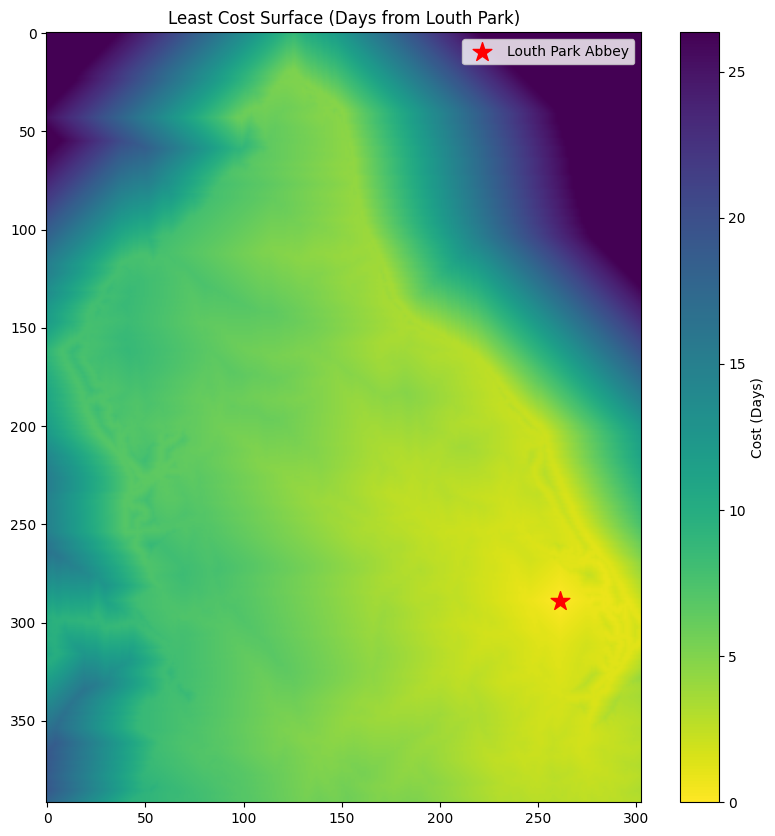

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cumulative_costs, cmap='viridis_r', origin='upper', vmax=np.percentile(cumulative_costs[cumulative_costs < 999], 95)) # Cap vmax for better viz
plt.colorbar(im, ax=ax, label='Cost (Days)')
ax.scatter([src_c], [src_r], c='red', marker='*', label='Louth Park Abbey', s=200, zorder=5)
ax.set_title('Least Cost Surface (Days from Louth Park)')
ax.legend()
plt.savefig(PROJECT_ROOT / 'Output/Images/Maps/news_day_cost_surface.png', dpi=300)
# plt.show()

## Plot Least Cost Surface with Route Overlays

Creating route overlay plot...
Plotting ancient parishes overlay...
Using county field: GAZ_CNTY
Plotting 15681 non-northern parishes...
Plotting 7048 northern parishes...
Plotting direct evidence...
Plotting indirect evidence...
Plotting Gough routes...
Plotting shipping routes...
Route overlay saved to c:\Users\nicho\My Drive\20_Projects\NRP---New-Rebellion-Paper\Output\Images\Maps\news_day_with_routes.png


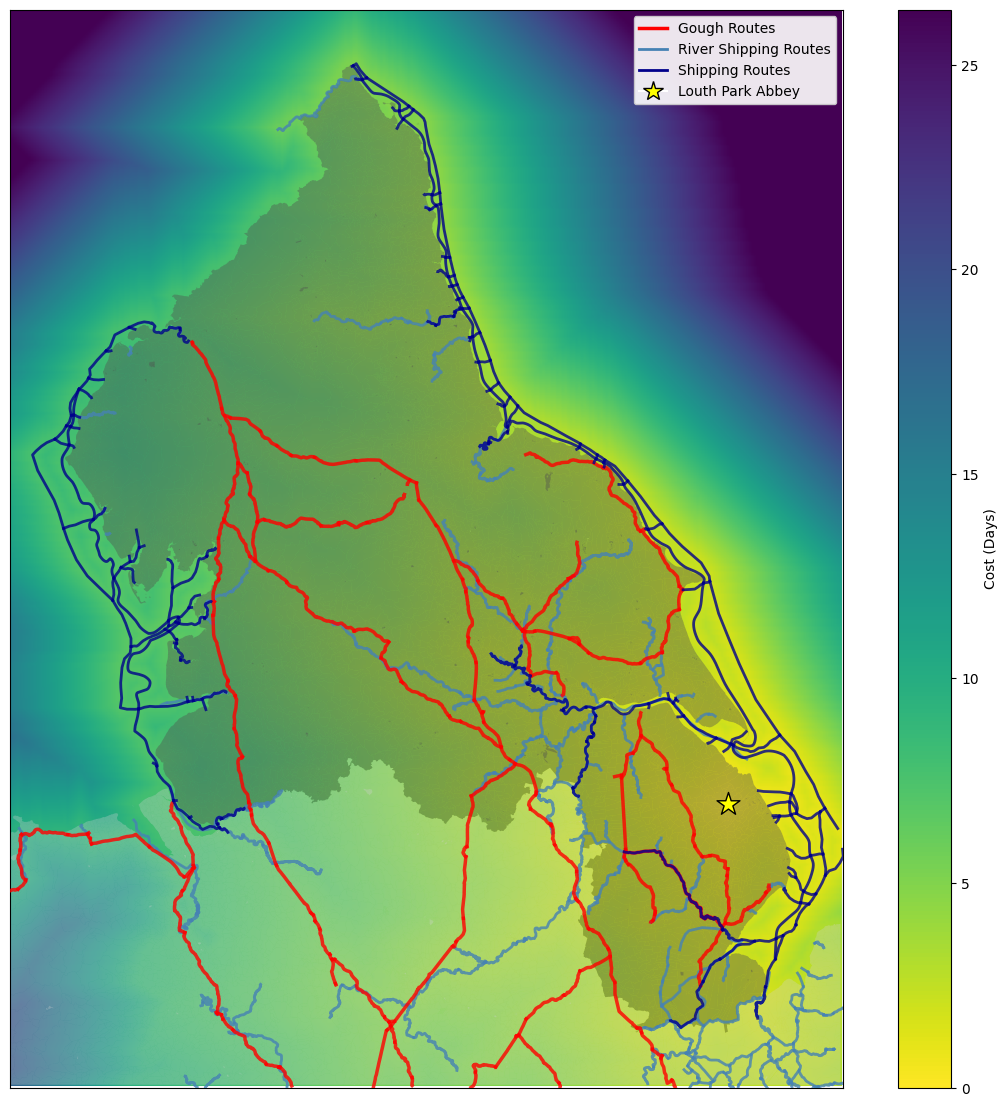

In [16]:
print("Creating route overlay plot...")

# Function to transform geometry coordinates to raster coordinates
def geom_to_raster_coords(gdf, inv_transform, height, width):
    """
    Convert geographic coordinates to raster row/col coordinates.
    Each LineString is kept separate to prevent artificial connections.
    Coordinates are clipped to raster bounds.
    """
    coords_list = []
    for geom in gdf.geometry:
        if geom.is_empty or geom is None:
            continue

        lines = []
        if geom.geom_type == 'LineString':
            lines = [geom]
        elif geom.geom_type == 'MultiLineString':
            lines = list(geom.geoms)
        else:
            continue

        for line in lines:
            coords = list(line.coords)
            raster_coords = []
            for x, y in coords:
                col, row = inv_transform * (x, y)
                if 0 <= row < height and 0 <= col < width:
                    raster_coords.append((col, row))
                else:
                    if raster_coords:
                        coords_list.append(raster_coords)
                        raster_coords = []
            if len(raster_coords) >= 2:
                coords_list.append(raster_coords)

    return coords_list

fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(cumulative_costs, cmap='viridis_r', origin='upper',
               vmax=np.percentile(cumulative_costs[cumulative_costs < 999], 95))
plt.colorbar(im, ax=ax, label='Cost (Days)')
ax.set_xlim(0, width)
ax.set_ylim(height, 0)

print("Plotting ancient parishes overlay...")

def plot_polygon_overlay(gdf, inv_transform, ax, color, alpha, height, width, label=None):
    """Plot polygons as overlay on raster, clipped to raster bounds"""
    from matplotlib.patches import Polygon as MPLPolygon
    from matplotlib.collections import PatchCollection

    patches = []
    for geom in gdf.geometry:
        if geom.is_empty or geom is None:
            continue
        polygons = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms) if geom.geom_type == 'MultiPolygon' else []
        for poly in polygons:
            coords = list(poly.exterior.coords)
            raster_coords = []
            all_in_bounds = True
            for x, y in coords:
                col, row = inv_transform * (x, y)
                raster_coords.append((col, row))
                if not (0 <= row < height and 0 <= col < width):
                    all_in_bounds = False
            if len(raster_coords) >= 3:
                cols, rows = zip(*raster_coords)
                if not (max(cols) < 0 or min(cols) >= width or max(rows) < 0 or min(rows) >= height):
                    clipped = [(max(0, min(width-1, c)), max(0, min(height-1, r))) for c, r in raster_coords]
                    patches.append(MPLPolygon(clipped, closed=True))
    if patches:
        ax.add_collection(PatchCollection(patches, facecolor=color, edgecolor='none', alpha=alpha, zorder=2))

county_field = next((f for f in ['GAZ_CNTY', 'county', 'County', 'COUNTY'] if f in ancient_parishes.columns), None)
if county_field:
    print(f"Using county field: {county_field}")
    northern_parishes = ancient_parishes[ancient_parishes[county_field].isin(north_list)]
    other_parishes = ancient_parishes[~ancient_parishes[county_field].isin(north_list)]
    print(f"Plotting {len(other_parishes)} non-northern parishes...")
    plot_polygon_overlay(other_parishes, inv_transform, ax, color='#D3D3D3', alpha=0.3, height=height, width=width)
    print(f"Plotting {len(northern_parishes)} northern parishes...")
    plot_polygon_overlay(northern_parishes, inv_transform, ax, color='#505050', alpha=0.4, height=height, width=width)
else:
    print("Warning: Could not find county field in ancient parishes shapefile")
    plot_polygon_overlay(ancient_parishes, inv_transform, ax, color='#D3D3D3', alpha=0.3, height=height, width=width)

medium_blue = '#4682B4'
dark_blue = '#00008B'
red = '#FF0000'

for label, gdf_r, color, lw in [
    ('direct evidence', direct_evidence, medium_blue, 2),
    ('indirect evidence', indirect_evidence, medium_blue, 2),
    ('Gough routes', gough_routes, red, 2.5),
    ('shipping routes', shipping, dark_blue, 2),
]:
    print(f"Plotting {label}...")
    for coords in geom_to_raster_coords(gdf_r, inv_transform, height, width):
        if len(coords) >= 2:
            cols, rows = zip(*coords)
            ax.plot(cols, rows, color=color, linewidth=lw, alpha=0.8, zorder=3)

ax.scatter([src_c], [src_r], c='yellow', marker='*', edgecolors='black', linewidths=1,
           label='Louth Park Abbey', s=300, zorder=6)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=red, linewidth=2.5, label='Gough Routes'),
    Line2D([0], [0], color=medium_blue, linewidth=2, label='River Shipping Routes'),
    Line2D([0], [0], color=dark_blue, linewidth=2, label='Shipping Routes'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
           markeredgecolor='black', markersize=15, label='Louth Park Abbey')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

output_path = PROJECT_ROOT / 'Output/Images/Maps/news_day_with_routes.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Route overlay saved to {output_path}")
# plt.show()